セル0

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score

# 必要モデルのインポート
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# ========================================================
# ⚙️ CONFIG（最初にここを自由に変更してください）
# ========================================================

MODEL_PREFIX = "0527_smart_run_"                     # モデルファイルを保存する際の接頭辞
# 🎯 2. 過学習対策 ＆ 爆速化のためのパラメータ
SEEDS = [42]   # 混ぜるシード値（爆速＆安定なら のみ。2つ混ぜるなら に増やす）

# 🤖 3. 各モデルのパラメータ設定（不均衡データ対応等）
LGBM_PARAMS = {
    "random_state": 42, 
    "verbose": -1, 
    "is_unbalance": True,
    "max_depth": 5,          # 🌲 木の深さを制限
    "num_leaves": 23,         # 🍃 葉の数も抑える
    "learning_rate": 0.05,    # 💧 低学習率でじっくり学習
    "n_estimators": 300       # その分、回数を少し増やす
}

CAT_PARAMS  = {
    "random_state": 42, 
    "verbose": 0, 
    "auto_class_weights": "Balanced",
    "depth": 5,              # 🌲 キャットも少し浅くする
    "l2_leaf_reg": 7         # 🛑 正則化を強めて暴走を止める
}

RF_PARAMS   = {
    "random_state": 42, 
    "n_jobs": -1, 
    "class_weight": "balanced",
    "max_depth": 10,         # 🌲 ランフォレの過学習を止める生命線
    "min_samples_leaf": 5    # 🍃 細かすぎるノイズの学習を禁止
}

NN_PARAMS   = {
    "random_state": 42, 
    "hidden_layer_sizes": (64, 32), # 🧠 ネットワークをあえて狭くする
    "alpha": 0.1,                  # 🛑 強めのL2正則化（ノイズ対策）
    "max_iter": 500, 
    "early_stopping": True
}

print("▶️ [START] Kaggle Smart 4-Model Pipeline を開始します。")

# ========================================================
# STEP 1: データの読み込みと初期設定
# ========================================================
raw_dir = "../../data/raw/"
save_dir = "../../model/"
results_dir = "../../results/"
os.makedirs(save_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

print("📦 生データ（raw）を読み込んでいます...")
train_df = pd.read_csv(os.path.join(raw_dir, "train.csv"))
test_df = pd.read_csv(os.path.join(raw_dir, "test.csv"))

y = train_df['Exited'].copy()
test_id = test_df['id'].copy()

train_features = train_df.drop(columns=['Exited']) if 'Exited' in train_df.columns else train_df.copy()
test_features = test_df.copy()
train_features['is_train'] = 1
test_features['is_train'] = 0

combined = pd.concat([train_features, test_features], axis=0).reset_index(drop=True)


# ========================================================
# STEP 2: 特徴量エンジニアリング（出し入れはここで調整！）
# ========================================================
print("🛠️ 特徴量エンジニアリングを実行中...")

# --- ⬇️ 不要な場合は、このブロックの頭に「#」をつけてコメントアウトしてください ⬇️ ---
# 【容疑者①】苗字の出現頻度（AI生成データではノイズ化している可能性大）
#surname_counts = combined['Surname'].value_counts()
#combined['Surname_Freq'] = combined['Surname'].map(surname_counts)

# 【容疑者②】伊藤さんの年齢ゾーンフラグ（固定の境界線がGBDTの邪魔をしている可能性あり）
#combined['is_young_stable'] = (combined['Age'] <= 38).astype(int)
#combined['is_active_churn'] = (combined['Age'] >= 39).astype(int)
#combined['is_peak_churn'] = ((combined['Age'] >= 40) & (combined['Age'] <= 60)).astype(int)
#combined['is_senior_retire'] = (combined['Age'] >= 65).astype(int)
# --- ⬆️ コメントアウト調整エリア ここまで ⬆️ ---


# --- ⬇️ データの物理的な死角を補う筋肉質な特徴量群（残すことを推奨） ⬇️ ---
#combined['save_age_prod2'] = ((combined['Age'] >= 40) & (combined['Age'] <= 60) & (combined['NumOfProducts'] == 2)).astype(int)
#combined['Is_Product_2'] = (combined['NumOfProducts'] == 2).astype(int)
#combined['Is_High_Product'] = (combined['NumOfProducts'] >= 3).astype(int)
#combined['is_prod1_inactive'] = ((combined['NumOfProducts'] == 1) & (combined['IsActiveMember'] == 0)).astype(int)
#combined['Is_Balance_Zero'] = (combined['Balance'] == 0).astype(int)
#combined['Balance_to_Salary_Ratio'] = combined['Balance'] / (combined['EstimatedSalary'] + 1)
#combined['CreditScore_by_Age'] = combined['CreditScore'] / combined['Age']
#combined['Geo_Product'] = combined['Geography'].astype(str) + "_" + combined['NumOfProducts'].astype(str)



▶️ [START] Kaggle Smart 4-Model Pipeline を開始します。
📦 生データ（raw）を読み込んでいます...
🛠️ 特徴量エンジニアリングを実行中...


セル1

In [2]:
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import lightgbm as lgb

# --- カテゴリ変数の処理とデータの再分離 ---
base_cat_cols = ['Geography', 'Gender']
cat_cols = [col for col in base_cat_cols if col in combined.columns]

for col in cat_cols:
    le = LabelEncoder()
    combined[col] = le.fit_transform(combined[col].astype(str))

drop_cols = ['id', 'CustomerId', 'Surname']
combined = combined.drop(columns=[col for col in drop_cols if col in combined.columns])

X = combined[combined['is_train'] == 1].drop(columns=['is_train']).reset_index(drop=True)
X_test = combined[combined['is_train'] == 0].drop(columns=['is_train']).reset_index(drop=True)
num_cols = [col for col in X.columns if col not in cat_cols]

print(f" -> データの成形完了。最終特徴量数: {X.shape}")

# --- クロスバリデーション (OOF生成) ---
folds = 5
oof_cat = np.zeros(len(X))
oof_lgb = np.zeros(len(X))
oof_rf  = np.zeros(len(X))
oof_nn  = np.zeros(len(X))

test_pred_cat = np.zeros(len(X_test))
test_pred_lgb = np.zeros(len(X_test))
test_pred_rf  = np.zeros(len(X_test))
test_pred_nn  = np.zeros(len(X_test))

print(f"🚀 1シード × 5Fold のクロスバリデーションを開始します...")

for s_idx, seed in enumerate(SEEDS):
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=seed)
    oof_cat_seed = np.zeros(len(X))
    oof_lgb_seed = np.zeros(len(X))
    oof_rf_seed  = np.zeros(len(X))
    oof_nn_seed  = np.zeros(len(X))
    
    LGBM_PARAMS["random_state"] = seed
    CAT_PARAMS["random_state"] = seed
    RF_PARAMS["random_state"] = seed
    NN_PARAMS["random_state"] = seed
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        X_train_lgb, X_val_lgb, X_test_lgb = X_train.copy(), X_val.copy(), X_test.copy()
        for col in cat_cols:
            X_train_lgb[col] = X_train_lgb[col].astype("category")
            X_val_lgb[col] = X_val_lgb[col].astype("category")
            X_test_lgb[col] = X_test_lgb[col].astype("category")
            
        X_train_cat, X_val_cat, X_test_cat = X_train.copy(), X_val.copy(), X_test.copy()
        for col in cat_cols:
            X_train_cat[col] = X_train_cat[col].astype(str)
            X_val_cat[col] = X_val_cat[col].astype(str)
            X_test_cat[col] = X_test_cat[col].astype(str)
            
        preprocessor_nn = ColumnTransformer(
            transformers=[
                ('num', StandardScaler(), num_cols),
                ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
            ]
        )
        X_train_nn = preprocessor_nn.fit_transform(X_train)
        X_val_nn = preprocessor_nn.transform(X_val)
        X_test_nn = preprocessor_nn.transform(X_test)
        
        # 1. CatBoost
        model_cat = CatBoostClassifier(**CAT_PARAMS, cat_features=cat_cols)
        model_cat.fit(X_train_cat, y_train)
        oof_cat_seed[val_idx] = model_cat.predict_proba(X_val_cat)[:, 1]
        test_pred_cat += model_cat.predict_proba(X_test_cat)[:, 1] / (len(SEEDS) * folds)
        
        # 2. LightGBM
        model_lgb = lgb.LGBMClassifier(**LGBM_PARAMS)
        model_lgb.fit(X_train_lgb, y_train)
        oof_lgb_seed[val_idx] = model_lgb.predict_proba(X_val_lgb)[:, 1]
        test_pred_lgb += model_lgb.predict_proba(X_test_lgb)[:, 1] / (len(SEEDS) * folds)
        
        # 3. RandomForest
        model_rf = RandomForestClassifier(**RF_PARAMS)
        model_rf.fit(X_train, y_train)
        oof_rf_seed[val_idx] = model_rf.predict_proba(X_val)[:, 1]
        test_pred_rf += model_rf.predict_proba(X_test)[:, 1] / (len(SEEDS) * folds)
        
        # 4. NeuralNet (MLP)
        model_nn = MLPClassifier(**NN_PARAMS)
        model_nn.fit(X_train_nn, y_train)
        oof_nn_seed[val_idx] = model_nn.predict_proba(X_val_nn)[:, 1]
        test_pred_nn += model_nn.predict_proba(X_test_nn)[:, 1] / (len(SEEDS) * folds)
        
    oof_cat += oof_cat_seed / len(SEEDS)
    oof_lgb += oof_lgb_seed / len(SEEDS)
    oof_rf  += oof_rf_seed / len(SEEDS)
    oof_nn  += oof_nn_seed / len(SEEDS)

# --- 黄金比率アンサンブル予測の確定 ---
oof_preds_matrix = np.column_stack([oof_cat, oof_lgb, oof_rf, oof_nn])
test_preds_matrix = np.column_stack([test_pred_cat, test_pred_lgb, test_pred_rf, test_pred_nn])

SEARCH_ITERATIONS = 1000
best_auc = 0
best_weights = None
np.random.seed(42)

for _ in range(SEARCH_ITERATIONS):
    w = np.random.rand(4)
    w = w / np.sum(w)
    ensemble_oof_pred = np.dot(oof_preds_matrix, w)
    auc = roc_auc_score(y, ensemble_oof_pred)
    if auc > best_auc:
        best_auc = auc
        best_weights = w

global_oof_preds = np.dot(oof_preds_matrix, best_weights)
global_test_preds = np.dot(test_preds_matrix, best_weights)

print(f"✨ ベースの全体アンサンブル予測が確定しました (ベースAUC: {best_auc:.5f})")

 -> データの成形完了。最終特徴量数: (15000, 10)
🚀 1シード × 5Fold のクロスバリデーションを開始します...
✨ ベースの全体アンサンブル予測が確定しました (ベースAUC: 0.93559)


In [85]:
import optuna
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

print("⏳ Optunaによる40-60歳エリア最適化パラメータの探索を開始（30トライアル）...")

# データの準備（前段のセルで成形済みのX, yを使用）
mask_4060 = (X['Age'] >= 40) & (X['Age'] <= 60)
X_local = X[mask_4060].copy()
y_local = y[mask_4060].copy()

local_cat_cols = ['Geography', 'Gender']

def objective(trial):
    # 探索空間の定義
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'verbose': -1,
        'random_state': 42,
        'is_unbalance': False,
        'scale_pos_weight': 1.0,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05),
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'num_leaves': trial.suggest_int('num_leaves', 7, 31),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 80),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': 1
    }
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof_preds = np.zeros(len(X_local))
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_local, y_local)):
        X_train, y_train = X_local.iloc[train_idx], y_local.iloc[train_idx]
        X_val, y_val_fold = X_local.iloc[val_idx], y_local.iloc[val_idx]
        
        train_dataset = lgb.Dataset(X_train, label=y_train, categorical_feature=local_cat_cols)
        val_dataset = lgb.Dataset(X_val, label=y_val_fold, reference=train_dataset, categorical_feature=local_cat_cols)
        
        model = lgb.train(
            params,
            train_dataset,
            num_boost_round=1500,
            valid_sets=[train_dataset, val_dataset],
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )
        
        oof_preds[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)
        
    return roc_auc_score(y_local, oof_preds)

# 最適化セッションの実行
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print("\n" + "="*40)
print("🏆 チューニング完了")
print("="*40)
print(f"ベストエリア内単体AUC: {study.best_value:.5f}")
print("設定すべきベストパラメータ群:")
for key, value in study.best_params.items():
    if isinstance(value, float):
        print(f"    '{key}': {value:.5f},")
    else:
        print(f"    '{key}': {value},")

⏳ Optunaによる40-60歳エリア最適化パラメータの探索を開始（30トライアル）...

🏆 チューニング完了
ベストエリア内単体AUC: 0.91105
設定すべきベストパラメータ群:
    'learning_rate': 0.03886,
    'max_depth': 3,
    'num_leaves': 9,
    'min_child_samples': 35,
    'feature_fraction': 0.75847,
    'bagging_fraction': 0.76001,


セル2

In [3]:
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

print("🚀 40-60歳エリア特化型・先鋭化ローカルモデル（年齢復元版）の学習を開始...")

# 1. 成形済みのX, X_testから40-60歳エリアを抽出（Age特徴量を保持）
mask_4060 = (X['Age'] >= 40) & (X['Age'] <= 60)
mask_4060_test = (X_test['Age'] >= 40) & (X_test['Age'] <= 60)

X_local = X[mask_4060].copy()
y_local = y[mask_4060].copy()
X_local_test = X_test[mask_4060_test].copy()

# 局所内（5067件）のOOFおよびテスト予測用配列
oof_local_zone = np.zeros(len(X_local))
test_pred_local_zone = np.zeros(len(X_local_test))

# 💡 先行セルで数値化されたカテゴリ変数の列名を定義
local_cat_cols = ['Geography', 'Gender']

# ⚙️ 局所・均衡データ環境（解約率45.08%）に最適化した先鋭化パラメータ群
lgb_params_local = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.03886,
    'max_depth': 3,
    'num_leaves': 9,
    'min_child_samples': 35,
    'feature_fraction': 0.75847,
    'bagging_fraction': 0.76001,
    'bagging_freq': 1,
    'is_unbalance': False,        # 均衡データのためオフ
    'scale_pos_weight': 1.0,      # 1:1のデータバランスのため1.0固定
    'verbose': -1,
    'random_state': 42
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_local, y_local)):
    X_train, y_train = X_local.iloc[train_idx], y_local.iloc[train_idx]
    X_val, y_val_fold = X_local.iloc[val_idx], y_local.iloc[val_idx]
    
    # 💡 【修正箇所】引数 categorical_feature を lgb.Dataset の構築時に指定
    train_dataset = lgb.Dataset(X_train, label=y_train, categorical_feature=local_cat_cols)
    val_dataset = lgb.Dataset(X_val, label=y_val_fold, reference=train_dataset, categorical_feature=local_cat_cols)
    
    # lgb.train 側からは引数 categorical_feature を除外
    model = lgb.train(
        lgb_params_local,
        train_dataset,
        num_boost_round=1500,
        valid_sets=[train_dataset, val_dataset],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    
    oof_local_zone[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)
    if len(X_local_test) > 0:
        test_pred_local_zone += model.predict(X_local_test, num_iteration=model.best_iteration) / skf.n_splits

# 2. エリア内単体AUCの算出と表示
local_auc_new = roc_auc_score(y_local, oof_local_zone)

print("\n" + "="*40)
print(f"🏆 年齢復元・パラメータ最適化後のエリア内単体AUC: {local_auc_new:.5f}")
print("="*40)

# 3. 後続のセル3（特徴量統合）との互換性を維持するため、全体サイズ（15000件）の配列へ再配置
oof_local = np.zeros(len(X))
test_pred_local = np.zeros(len(X_test))

oof_local[mask_4060] = oof_local_zone
test_pred_local[mask_4060_test] = test_pred_local_zone

print("✨ 後続のメタ特徴量（oof_local / test_pred_local）への格納が完了しました。")

🚀 40-60歳エリア特化型・先鋭化ローカルモデル（年齢復元版）の学習を開始...

🏆 年齢復元・パラメータ最適化後のエリア内単体AUC: 0.90963
✨ 後続のメタ特徴量（oof_local / test_pred_local）への格納が完了しました。


セル3

In [4]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

print("📦 スタッキング用のデータ ＆ ベースとなる全体アンサンブルを同時作成中...")

# 1. 最初にうまくいったシンプルなスタッキング用特徴量を構成
X_meta = pd.DataFrame({
    'pred_cat': oof_cat,
    'pred_lgb': oof_lgb,
    'pred_rf': oof_rf,
    'pred_nn': oof_nn,
    'pred_local': oof_local,                     # 40-60歳以外は0
    'Age': X['Age'].values,                      # 生の年齢
    'is_4060': ((X['Age'] >= 40) & (X['Age'] <= 60)).astype(int) # 40-60歳エリアフラグ
})

X_meta_test = pd.DataFrame({
    'pred_cat': test_pred_cat,
    'pred_lgb': test_pred_lgb,
    'pred_rf': test_pred_rf,
    'pred_nn': test_pred_nn,
    'pred_local': test_pred_local,
    'Age': X_test['Age'].values,
    'is_4060': ((X_test['Age'] >= 40) & (X_test['Age'] <= 60)).astype(int)
})

# 2. 修正前の4モデルの黄金比率アンサンブルを作成
oof_preds_matrix = np.column_stack([oof_cat, oof_lgb, oof_rf, oof_nn])
test_preds_matrix = np.column_stack([test_pred_cat, test_pred_lgb, test_pred_rf, test_pred_nn])

SEARCH_ITERATIONS = 1000
best_auc = 0
best_weights = None
np.random.seed(42)

for _ in range(SEARCH_ITERATIONS):
    w = np.random.rand(4)
    w = w / np.sum(w)
    ensemble_oof_pred = np.dot(oof_preds_matrix, w)
    auc = roc_auc_score(y, ensemble_oof_pred)
    
    if auc > best_auc:
        best_auc = auc
        best_weights = w

# 修正前のベース予測を確定
global_oof_preds = np.dot(oof_preds_matrix, best_weights)
global_test_preds = np.dot(test_preds_matrix, best_weights)

print(f"✨ ベースの全体アンサンブル予測が確定しました (ベースAUC: {best_auc:.5f})")

📦 スタッキング用のデータ ＆ ベースとなる全体アンサンブルを同時作成中...
✨ ベースの全体アンサンブル予測が確定しました (ベースAUC: 0.93559)


📊 40-60歳エリア限定・年齢隠しローカルモデルの純粋な実力を可視化中...


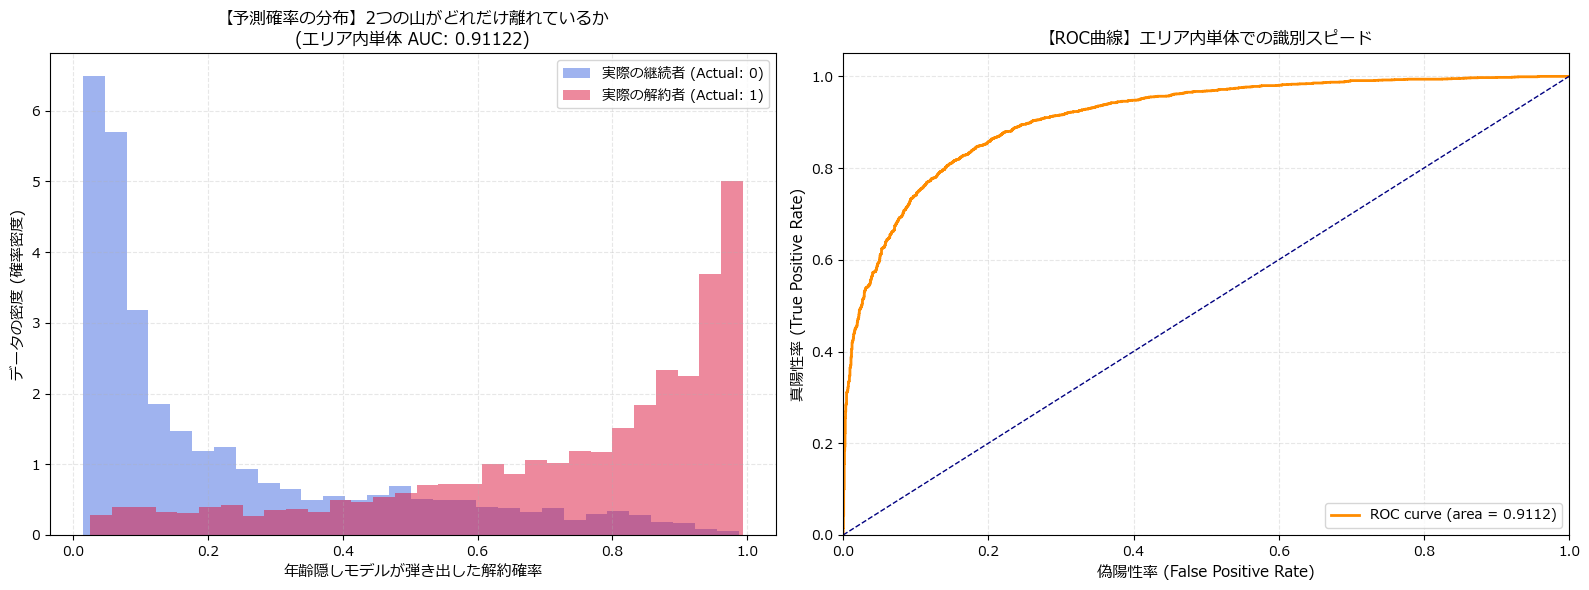

In [88]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, roc_auc_score

print("📊 40-60歳エリア限定・年齢隠しローカルモデルの純粋な実力を可視化中...")

# 1. 40-60歳エリアのデータと「年齢隠しモデルの予測値」を抽出
mask_4060 = (X['Age'] >= 40) & (X['Age'] <= 60)
y_local = y[mask_4060].values
pred_local_zone = oof_local[mask_4060]

local_auc = roc_auc_score(y_local, pred_local_zone)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Meiryo', 'MS Gothic', 'AppleGothic', 'YuGothic', 'Noto Sans CJK JP', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False 

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 🔵 左画面：実際の継続者・解約者ごとの予測確率の分布（ヒストグラム） ---
# 💡 axes の後ろの角括弧の数字を全角にしています（y_local == 0 は条件式なので半角です）
axes[0].hist(pred_local_zone[y_local == 0], bins=30, alpha=0.5, color='royalblue', label='実際の継続者 (Actual: 0)', density=True)
axes[0].hist(pred_local_zone[y_local == 1], bins=30, alpha=0.5, color='crimson', label='実際の解約者 (Actual: 1)', density=True)
axes[0].set_title(f"【予測確率の分布】2つの山がどれだけ離れているか\n(エリア内単体 AUC: {local_auc:.5f})", fontsize=12)
axes[0].set_xlabel("年齢隠しモデルが弾き出した解約確率", fontsize=11)
axes[0].set_ylabel("データの密度 (確率密度)", fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.3)
axes[0].legend(loc='upper right')

# --- 🔴 右画面：40-60歳エリア単体のROC曲線 ---
fpr, tpr, _ = roc_curve(y_local, pred_local_zone)
# 💡 axes の後ろの角括弧の数字を全角にしています
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (area = {local_auc:.4f})")
axes[1].plot([0.0, 1.0], [0.0, 1.0], color='navy', lw=1, linestyle='--') # 💡 小数リストなので半角です
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_title("【ROC曲線】エリア内単体での識別スピード", fontsize=12)
axes[1].set_xlabel("偽陽性率 (False Positive Rate)", fontsize=11)
axes[1].set_ylabel("真陽性率 (True Positive Rate)", fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.3)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

📊 40-60歳ローカルモデル予測確率の0.1刻み分布（エリア内限定）を集計中...

📋 --- 40-60歳ローカルモデルの確率区間別・正解ラベル件数一覧 ---
         継続 (Actual: 0)  解約 (Actual: 1)
bin                                    
0.0-0.1            1296              61
0.1-0.2             468              74
0.2-0.3             277              83
0.3-0.4             163              89
0.4-0.5             161             121
0.5-0.6             137             160
0.6-0.7             104             215
0.7-0.8              91             257
0.8-0.9              60             429
0.9-1.0              26             795
--------------------------------------------------
対象エリア合計件数: 5067 件
--------------------------------------------------


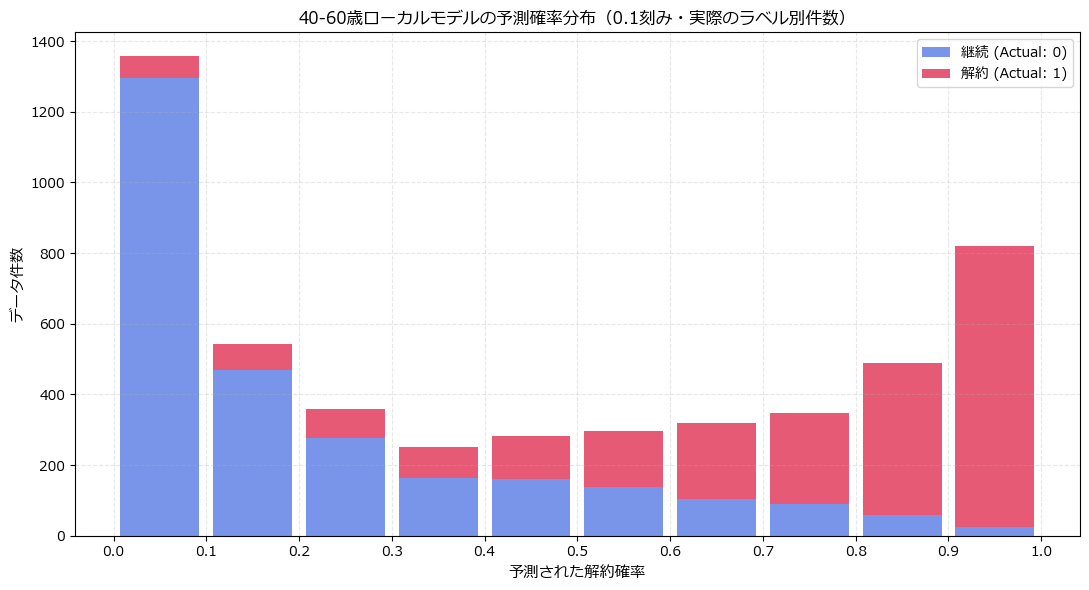

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("📊 40-60歳ローカルモデル予測確率の0.1刻み分布（エリア内限定）を集計中...")

# 40-60歳エリアのデータと予測確率を抽出
mask_4060 = (X['Age'] >= 40) & (X['Age'] <= 60)
local_probs = oof_local[mask_4060]
y_zone = y[mask_4060]

# 1. 0.1刻みの区切り（ビン）とラベルを定義
bins = np.arange(0, 1.1, 0.1)
labels = [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(len(bins)-1)]

# 予測確率と実際の正解ラベルをデータフレームに統合
df_local_dist = pd.DataFrame({
    'pred': local_probs,
    'actual': y_zone.values
})

# 確率を0.1刻みの区間にマッピング
df_local_dist['bin'] = pd.cut(df_local_dist['pred'], bins=bins, labels=labels, include_lowest=True)

# 2. 継続(0)と解約(1)の件数をクロス集計（テキスト出力用）
cross_tab_local = pd.crosstab(df_local_dist['bin'], df_local_dist['actual'])
cross_tab_local.columns = ['継続 (Actual: 0)', '解約 (Actual: 1)']

print("\n📋 --- 40-60歳ローカルモデルの確率区間別・正解ラベル件数一覧 ---")
print(cross_tab_local)
print("-" * 50)
print(f"対象エリア合計件数: {cross_tab_local.sum().sum()} 件")
print("-" * 50)

# 3. 積み上げヒストグラムによる視覚化
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Meiryo', 'MS Gothic', 'AppleGothic', 'YuGothic', 'Noto Sans CJK JP', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(11, 6))

# 継続と解約を積み上げて、各ビンの絶対件数を可視化
ax.hist([local_probs[y_zone == 0], local_probs[y_zone == 1]], 
        bins=bins, stacked=True, color=['royalblue', 'crimson'], 
        alpha=0.7, label=['継続 (Actual: 0)', '解約 (Actual: 1)'], rwidth=0.85)

ax.set_title("40-60歳ローカルモデルの予測確率分布（0.1刻み・実際のラベル別件数）", fontsize=12)
ax.set_xlabel("予測された解約確率", fontsize=11)
ax.set_ylabel("データ件数", fontsize=11)
ax.set_xticks(bins)
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

📊 全体モデルの40-60歳ゾーン限定・予測確率の0.1刻み分布を集計中...

📋 --- 全体モデル（40-60歳ゾーン限定）の確率区間別・正解ラベル件数一覧 ---
         継続 (Actual: 0)  解約 (Actual: 1)
bin                                    
0.0-0.1             643              19
0.1-0.2             590              34
0.2-0.3             361              40
0.3-0.4             228              57
0.4-0.5             226              63
0.5-0.6             148              89
0.6-0.7             183             148
0.7-0.8             185             246
0.8-0.9             136             424
0.9-1.0              83            1164
--------------------------------------------------
40-60歳ゾーン合計件数: 5067 件
--------------------------------------------------


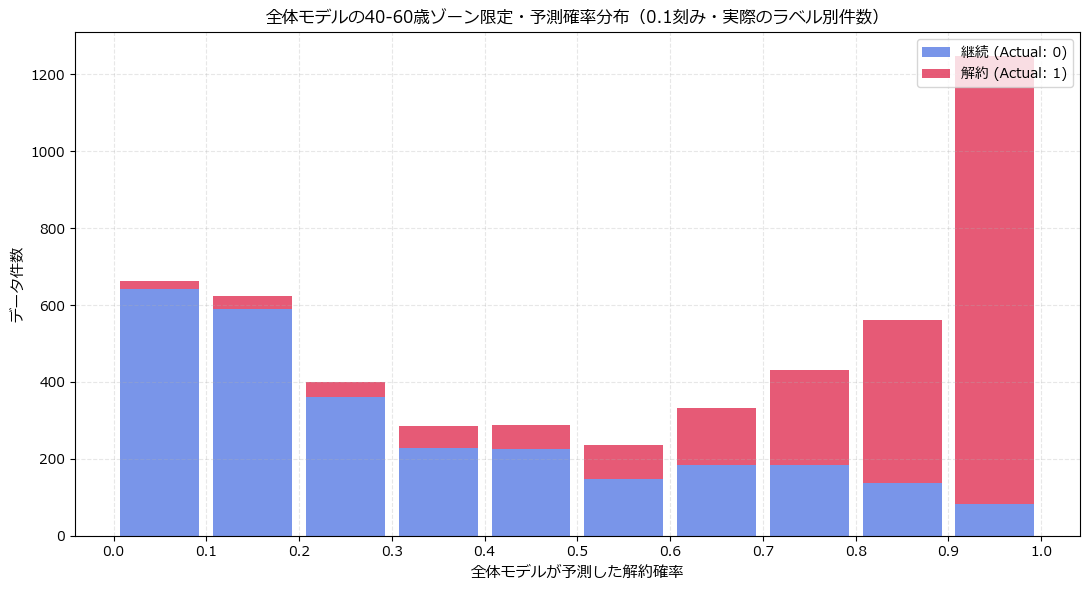

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("📊 全体モデルの40-60歳ゾーン限定・予測確率の0.1刻み分布を集計中...")

# 40-60歳エリアのデータと全体モデルの予測確率を抽出
mask_4060 = (X['Age'] >= 40) & (X['Age'] <= 60)
global_probs_zone = global_oof_preds[mask_4060]
y_zone = y[mask_4060]

# 1. 0.1刻みの区切り（ビン）とラベルを定義
bins = np.arange(0, 1.1, 0.1)
labels = [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(len(bins)-1)]

# 予測確率と実際の正解ラベルをデータフレームに統合
df_zone_dist = pd.DataFrame({
    'pred': global_probs_zone,
    'actual': y_zone.values
})

# 確率を0.1刻みの区間にマッピング
df_zone_dist['bin'] = pd.cut(df_zone_dist['pred'], bins=bins, labels=labels, include_lowest=True)

# 2. 継続(0)と解約(1)の件数をクロス集計（テキスト出力用）
cross_tab_zone = pd.crosstab(df_zone_dist['bin'], df_zone_dist['actual'])
cross_tab_zone.columns = ['継続 (Actual: 0)', '解約 (Actual: 1)']

print("\n📋 --- 全体モデル（40-60歳ゾーン限定）の確率区間別・正解ラベル件数一覧 ---")
print(cross_tab_zone)
print("-" * 50)
print(f"40-60歳ゾーン合計件数: {cross_tab_zone.sum().sum()} 件")
print("-" * 50)

# 3. 積み上げヒストグラムによる視覚化
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Meiryo', 'MS Gothic', 'AppleGothic', 'YuGothic', 'Noto Sans CJK JP', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(11, 6))

# 継続と解約を積み上げて、各ビンの絶対件数を可視化
ax.hist([global_probs_zone[y_zone == 0], global_probs_zone[y_zone == 1]], 
        bins=bins, stacked=True, color=['royalblue', 'crimson'], 
        alpha=0.7, label=['継続 (Actual: 0)', '解約 (Actual: 1)'], rwidth=0.85)

ax.set_title("全体モデルの40-60歳ゾーン限定・予測確率分布（0.1刻み・実際のラベル別件数）", fontsize=12)
ax.set_xlabel("全体モデルが予測した解約確率", fontsize=11)
ax.set_ylabel("データ件数", fontsize=11)
ax.set_xticks(bins)
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

📊 40-60歳エリアにおける『全体モデル vs ローカルモデル』の相関図を生成中...


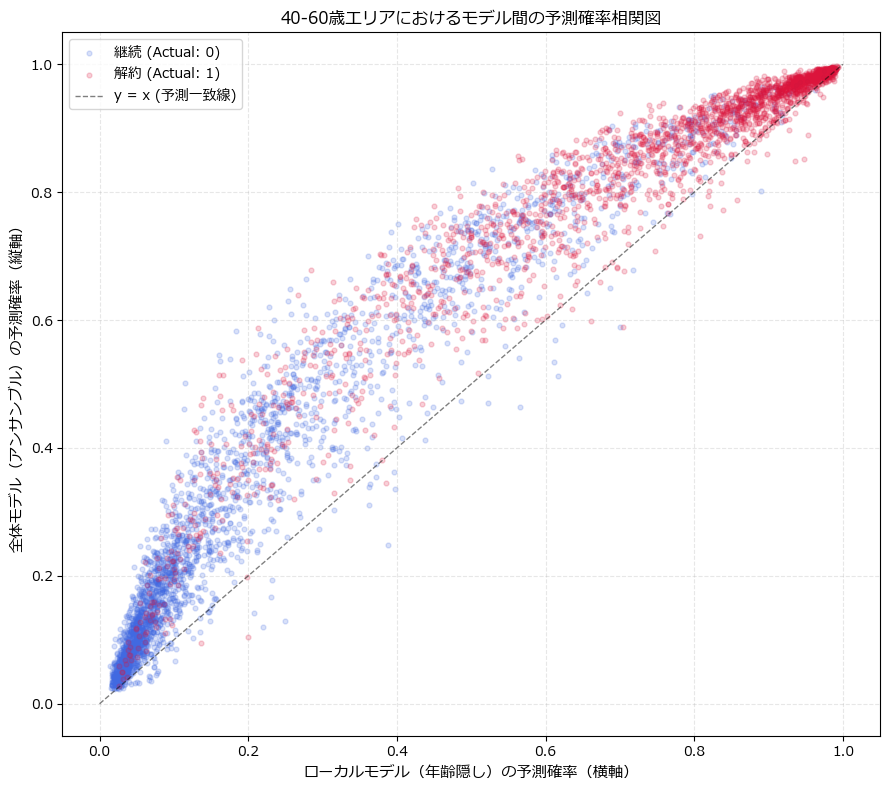

In [91]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("📊 40-60歳エリアにおける『全体モデル vs ローカルモデル』の相関図を生成中...")

# 40-60歳エリアの抽出
mask_4060 = (X['Age'] >= 40) & (X['Age'] <= 60)
x_val = oof_local[mask_4060]
y_val = global_oof_preds[mask_4060]
labels = y[mask_4060].values

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Meiryo', 'MS Gothic', 'AppleGothic', 'YuGothic', 'Noto Sans CJK JP', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(9, 8))

# 実際の正解ラベル（継続：青、解約：赤）で色分けしてプロット
ax.scatter(x_val[labels == 0], y_val[labels == 0], alpha=0.2, c='royalblue', label='継続 (Actual: 0)', s=12)
ax.scatter(x_val[labels == 1], y_val[labels == 1], alpha=0.2, c='crimson', label='解約 (Actual: 1)', s=12)

# 基準線（予測が完全に一致する場合の直線 y = x）
ax.plot([0.0, 1.0], [0.0, 1.0], color='black', linestyle='--', lw=1, alpha=0.5, label='y = x (予測一致線)')

ax.set_title("40-60歳エリアにおけるモデル間の予測確率相関図", fontsize=12)
ax.set_xlabel("ローカルモデル（年齢隠し）の予測確率（横軸）", fontsize=11)
ax.set_ylabel("全体モデル（アンサンブル）の予測確率（縦軸）", fontsize=11)
ax.set_xlim([-0.05, 1.05])
ax.set_ylim([-0.05, 1.05])
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [92]:
import numpy as np
import pandas as pd

print("⏳ 40-60歳エリアにおける『全体モデル × ローカルモデル』の2次元分布を集計中...")

# 1. 40-60歳エリアのデータを抽出
mask_4060 = (X['Age'] >= 40) & (X['Age'] <= 60)
global_probs_zone = global_oof_preds[mask_4060]
local_probs_zone = oof_local[mask_4060]
y_zone = y[mask_4060].values

# 0.1刻みの区切り（ビン）とラベルを定義
bins = np.arange(0, 1.1, 0.1)
labels = [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(len(bins)-1)]

# 2. それぞれの確率を0.1刻みの区間に分類
global_binned = pd.cut(global_probs_zone, bins=bins, labels=labels, include_lowest=True)
local_binned = pd.cut(local_probs_zone, bins=bins, labels=labels, include_lowest=True)

# 3. 2次元クロス集計（マトリックス）の生成
# ① 合計件数マトリックス
matrix_total = pd.crosstab(global_binned, local_binned, rownames=['全体モデル（縦軸）'], colnames=['ローカルモデル（横軸）'])

# ② 実際の継続者 (Actual: 0) 限定のマトリックス
matrix_actual_0 = pd.crosstab(global_binned[y_zone == 0], local_binned[y_zone == 0], rownames=['全体モデル（縦軸）'], colnames=['ローカルモデル（横軸）'])

# ③ 実際の解約者 (Actual: 1) 限定のマトリックス
matrix_actual_1 = pd.crosstab(global_binned[y_zone == 1], local_binned[y_zone == 1], rownames=['全体モデル（縦軸）'], colnames=['ローカルモデル（横軸）'])

# --- 結果のテキスト出力 ---
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 1000)

print("\n==========================================================================")
print("📊 1. 40-60歳エリア：【全体件数】マトリックス")
print("==========================================================================")
print(matrix_total)

print("\n==========================================================================")
print("🔵 2. 40-60歳エリア：【実際の継続者 (Actual: 0)】のみの件数マトリックス")
print("==========================================================================")
print(matrix_actual_0)

print("\n==========================================================================")
print("🔴 3. 40-60歳エリア：【実際の解約者 (Actual: 1)】のみの件数マトリックス")
print("==========================================================================")
print(matrix_actual_1)

⏳ 40-60歳エリアにおける『全体モデル × ローカルモデル』の2次元分布を集計中...

📊 1. 40-60歳エリア：【全体件数】マトリックス
ローカルモデル（横軸）  0.0-0.1  0.1-0.2  0.2-0.3  0.3-0.4  0.4-0.5  0.5-0.6  0.6-0.7  0.7-0.8  0.8-0.9  0.9-1.0
全体モデル（縦軸）                                                                                            
0.0-0.1          659        3        0        0        0        0        0        0        0        0
0.1-0.2          546       72        6        0        0        0        0        0        0        0
0.2-0.3          143      242       15        1        0        0        0        0        0        0
0.3-0.4            8      168       84       25        0        0        0        0        0        0
0.4-0.5            1       48      176       53        9        2        0        0        0        0
0.5-0.6            0        9       68      100       39       14        6        1        0        0
0.6-0.7            0        0       11       67      156       72       23        2        0        0
0.7-0.8

セル4

In [5]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

print("⚡ パラメータ変数化版：『中間層・左上滞留ゾーン』のピンポイント控除を実行中...")

mask_4060 = (X['Age'] >= 40) & (X['Age'] <= 60)
mask_4060_test = (X_test['Age'] >= 40) & (X_test['Age'] <= 60)

global_oof_zone = global_oof_preds[mask_4060]
local_oof_zone = oof_local[mask_4060]

global_test_zone = global_test_preds[mask_4060_test]
local_test_zone = test_pred_local[mask_4060_test]

# ========================================================
# ⚙️ 調整用ハイパーパラメータ設定（ここを変更するだけで連動します）
# ========================================================
# 1. 補正対象とする全体モデルの確率レンジ（縦軸の範囲）
global_target_min = 0.0
global_target_max = 0.70

# 2. 補正対象とするローカルモデルの上限値（横軸のカットオフ）
# 💡 ここを 0.20 や 0.10 に絞ることで、引き下げる「純度」をコントロールできます
local_cutoff_max = 0.30

# 3. 引き下げの強度（0.0：補正なし 〜 1.0：ローカルに完全同調）
alpha = 0.15 
# ========================================================

# 1. 訓練データに対するピンポイント抽出条件の適用
correction_mask = (
    (global_oof_zone >= global_target_min) & 
    (global_oof_zone <= global_target_max) & 
    (local_oof_zone <= local_cutoff_max)
)

# 2. テストデータに対する同様の抽出条件の適用
correction_mask_test = (
    (global_test_zone >= global_target_min) & 
    (global_test_zone <= global_target_max) & 
    (local_test_zone <= local_cutoff_max)
)

# 3. サイズ不一致（ValueError）を防ぐための作業用配列の作成
zone_oof_preds = global_oof_zone.copy()
zone_test_preds = global_test_zone.copy()

# 4. 条件合致セクターのみ、モデル間の乖離度に応じた引き下げ処理を適用
diff_oof = global_oof_zone - local_oof_zone
zone_oof_preds[correction_mask] = global_oof_zone[correction_mask] - (alpha * diff_oof[correction_mask])

diff_test = global_test_zone - local_test_zone
zone_test_preds[correction_mask_test] = global_test_zone[correction_mask_test] - (alpha * diff_test[correction_mask_test])

# 5. 変形済みのエリア内予測値を、全体のベース予測配列（final_blended_oof）へはめ込み
final_blended_oof = global_oof_preds.copy()
final_blended_oof[mask_4060] = zone_oof_preds

final_auc = roc_auc_score(y, final_blended_oof)

print("\n" + "="*40)
print("ピンポイント限定補正完了")
print("="*40)
print(f"修正前の全体AUC : {best_auc:.5f}")
print(f"修正後の全体AUC : {final_auc:.5f}")
print(f"現在の設定 - 全体レンジ: {global_target_min}〜{global_target_max} | ローカル上限: {local_cutoff_max} | 強度(alpha): {alpha}")
print(f"対象領域の補正件数 (Train) : {correction_mask.sum()} 件 / 5067 件中")

⚡ パラメータ変数化版：『中間層・左上滞留ゾーン』のピンポイント控除を実行中...

ピンポイント限定補正完了
修正前の全体AUC : 0.93559
修正後の全体AUC : 0.93562
現在の設定 - 全体レンジ: 0.0〜0.7 | ローカル上限: 0.3 | 強度(alpha): 0.15
対象領域の補正件数 (Train) : 2252 件 / 5067 件中


セル5

In [6]:
# ========================================================
# STEP 6: Kaggle用提出用CSV作成
# ========================================================
SUBMISSION_FILENAME = "submission_0526_matrix_patch.csv"
print(f"補正予測値をテストデータに適用し、提出用CSV '{SUBMISSION_FILENAME}' を作成中...")

final_test_preds = global_test_preds.copy()
# Cell 4 で作成した、安全圏保護＋中間層引き下げ済みの配列を代入
final_test_preds[mask_4060_test] = zone_test_preds

submission = pd.DataFrame({"id": test_id, "Exited": final_test_preds})
submission.to_csv(SUBMISSION_FILENAME, index=False)

print("\n" + "="*40)
print(f"提出ファイル出力完了：'{SUBMISSION_FILENAME}'")
print("="*40)
print(submission.head(3))

補正予測値をテストデータに適用し、提出用CSV 'submission_0526_matrix_patch.csv' を作成中...

提出ファイル出力完了：'submission_0526_matrix_patch.csv'
      id    Exited
0  15000  0.896418
1  15001  0.766847
2  15002  0.092743


セル6

予測分布図（中間層ピンポイント引き下げ前後）を生成中...


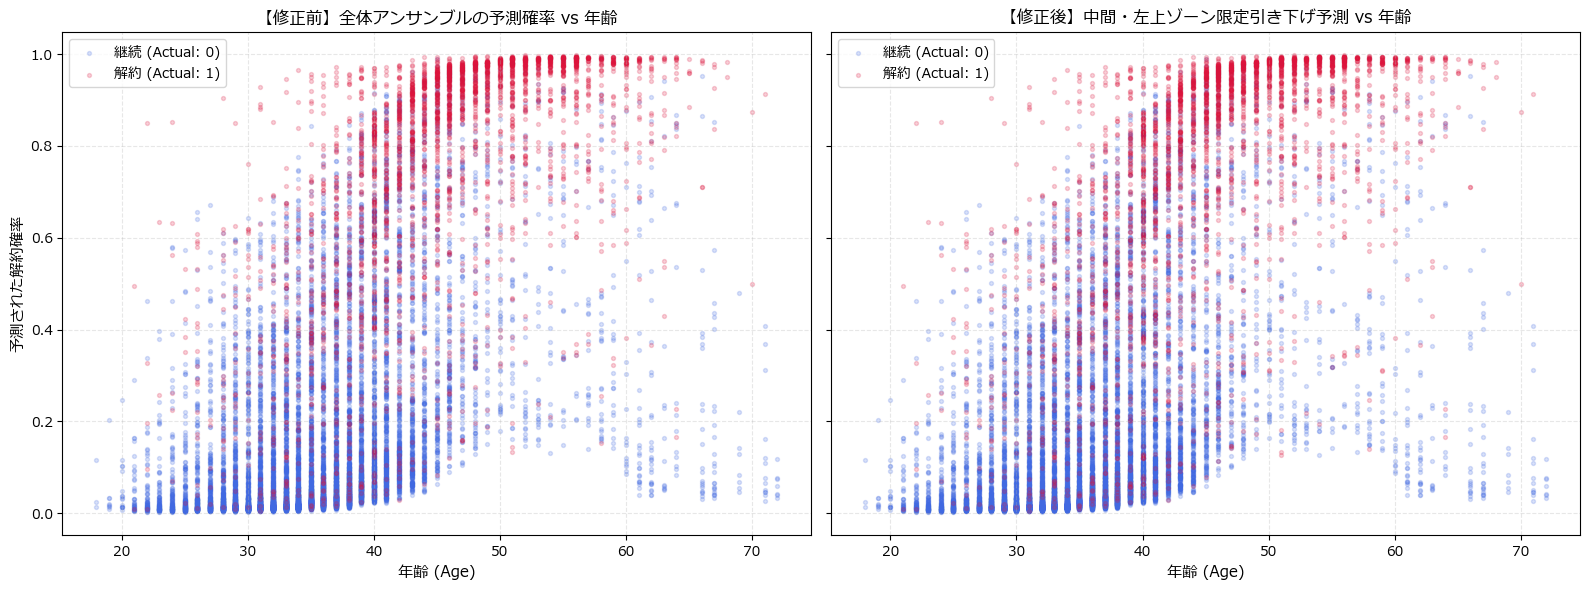

In [109]:
import matplotlib.pyplot as plt

print("予測分布図（中間層ピンポイント引き下げ前後）を生成中...")

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Meiryo', 'MS Gothic', 'AppleGothic', 'YuGothic', 'Noto Sans CJK JP', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False 

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# --- 左画面：修正前の全体アンサンブル予測 ---
axes[0].scatter(X['Age'][y == 0], global_oof_preds[y == 0], alpha=0.2, c='royalblue', label='継続 (Actual: 0)', s=8)
axes[0].scatter(X['Age'][y == 1], global_oof_preds[y == 1], alpha=0.2, c='crimson', label='解約 (Actual: 1)', s=8)
axes[0].set_title("【修正前】全体アンサンブルの予測確率 vs 年齢", fontsize=12)
axes[0].set_xlabel("年齢 (Age)", fontsize=11)
axes[0].set_ylabel("予測された解約確率", fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.3)
axes[0].legend(loc='upper left')

# --- 右画面：修正後のピンポイント引き下げ予測 ---
axes[1].scatter(X['Age'][y == 0], final_blended_oof[y == 0], alpha=0.2, c='royalblue', label='継続 (Actual: 0)', s=8)
axes[1].scatter(X['Age'][y == 1], final_blended_oof[y == 1], alpha=0.2, c='crimson', label='解約 (Actual: 1)', s=8)
axes[1].set_title("【修正後】中間・左上ゾーン限定引き下げ予測 vs 年齢", fontsize=12)
axes[1].set_xlabel("年齢 (Age)", fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.3)
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

In [28]:
# 💡 訓練データ（train_df）から40〜60歳のデータを抽出します
mask_4060 = (train_df['Age'] >= 40) & (train_df['Age'] <= 60)
df_4060 = train_df[mask_4060]

# 1. 件数の算出
count_4060 = len(df_4060)
total_train = len(train_df)
ratio_of_total = (count_4060 / total_train) * 100

# 2. 実際の解約者（Exited == 1）の数と割合（ベースレート）
churn_count_4060 = df_4060['Exited'].sum()
churn_rate_4060 = df_4060['Exited'].mean() * 100

print(f"📦 訓練データ（Train）全体の件数 : {total_train} 件")
print(f"📦 40〜60歳のデータ件数           : {count_4060} 件 (全体の {ratio_of_total:.2f} %)")
print("-" * 50)
print(f"🔴 40〜60歳の中での実際の解約者数 : {churn_count_4060} 件")
print(f"🔥 40〜60歳の【実際の解約率】     : {churn_rate_4060:.2f} %")

📦 訓練データ（Train）全体の件数 : 15000 件
📦 40〜60歳のデータ件数           : 5067 件 (全体の 33.78 %)
--------------------------------------------------
🔴 40〜60歳の中での実際の解約者数 : 2284.0 件
🔥 40〜60歳の【実際の解約率】     : 45.08 %
